<>:118: SyntaxWarning: invalid escape sequence '\D'
<>:118: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1588/2971651459.py:118: SyntaxWarning: invalid escape sequence '\D'
  text_str = f"$\Delta\mu$ Dynamics:\nStart Offset $\\approx -0.52$\nEnd Offset $\\approx -0.011$"


🚀 启动【高分辨率 100点】参数空间地毯式扫描...

目标 U_C     | 起始 μ (n=1)   | 结束 μ (n=10^7)  | R²       | 平均误差
-----------------------------------------------------------------
1.3000       | 0.7783         | 1.2885            | 0.7276   | 14.9468
1.3035       | 0.7818         | 1.2920            | 0.7276   | 14.9468
1.3071       | 0.7853         | 1.2955            | 0.7276   | 14.9468
1.3106       | 0.7889         | 1.2991            | 0.8508   | 12.1807
1.3141       | 0.7924         | 1.3026            | 0.9224   | 10.0766
1.3177       | 0.7959         | 1.3061            | 0.9324   | 8.8975
1.3212       | 0.7995         | 1.3097            | 0.9493   | 9.3013
1.3247       | 0.8030         | 1.3132            | 0.9565   | 8.2472
1.3283       | 0.8065         | 1.3167            | 0.9725   | 7.2594
1.3318       | 0.8101         | 1.3203            | 0.9713   | 7.7633
1.3354       | 0.8136         | 1.3238            | 0.9758   | 7.4572
1.3389       | 0.8171         | 1.3273            | 0.9828   | 5.6485

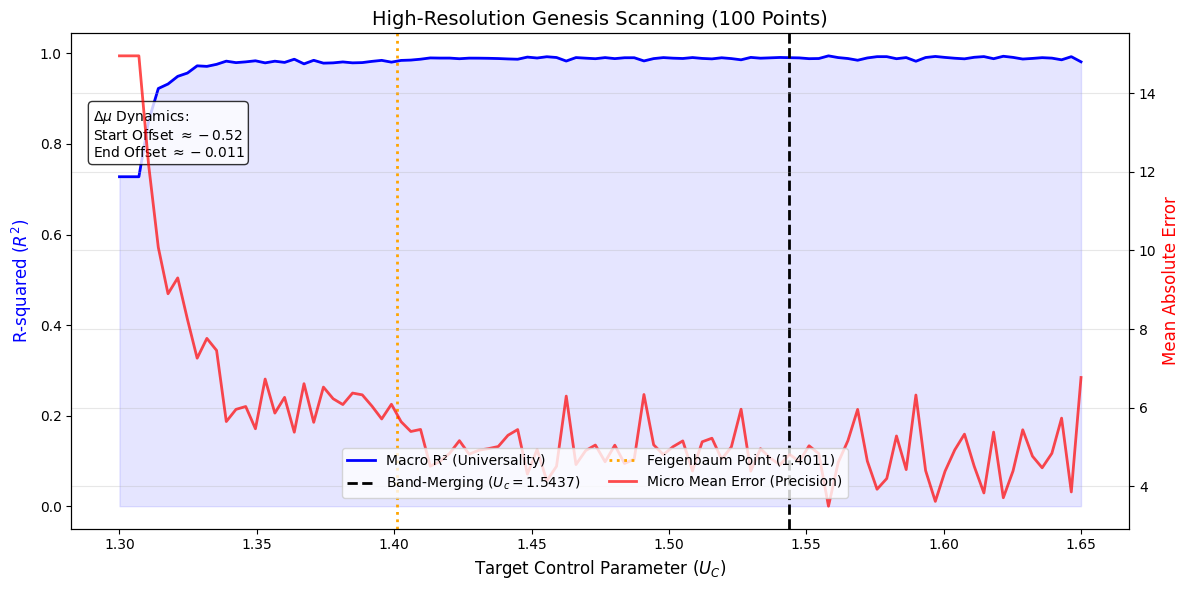

In [1]:
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import eigs
from scipy.stats import linregress
import mpmath
import matplotlib.pyplot as plt
import time
from numba import njit

# 真实的黎曼零点
mpmath.mp.dps = 15
N_ZEROS = 100
TRUE_ZEROS = np.array([float(mpmath.zetazero(i).imag) for i in range(1, N_ZEROS + 1)])

@njit
def run_universe_genesis(steps, n_bins, u_c, k_opt, c_offset):
    transitions = np.zeros((n_bins, n_bins), dtype=np.uint32)
    x = 0.5
    last_bin = int((x + 1.0) / 2.0 * (n_bins - 1))
    
    for i in range(1, steps + 1):
        # 从左侧（周期区）向上攀升
        mu_raw = u_c - k_opt / (np.log(i + c_offset)**2)
        # 保险丝：确保 mu 不会掉到 0 以下
        mu = max(mu_raw, 0.1) 
        
        x = 1.0 - mu * x * x
        if x > 1.0: x = 0.999
        elif x < -1.0: x = -0.999
            
        current_bin = int((x + 1.0) / 2.0 * (n_bins - 1))
        transitions[last_bin, current_bin] += 1
        last_bin = current_bin
        
    return transitions

# 🎯 高分辨率网格：100 个探测点
# 范围设定在 1.30 到 1.65 之间，刚好跨越费根鲍姆点和带合并点
test_points = np.linspace(1.30, 1.65, 100)
results_R2 = []
results_mean_err = []

total_steps = 10**7
K_OPT = 3.0       
C_OFFSET = 10.0   

print("🚀 启动【高分辨率 100点】参数空间地毯式扫描...\n")
print(f"{'目标 U_C':<10} | {'起始 μ (n=1)':<12} | {'结束 μ (n=10^7)':<14} | {'R²':<8} | {'平均误差'}")
print("-" * 65)

start_total_t = time.time()

for u in test_points:
    # 提前计算并打印演化的物理区间
    mu_start_raw = u - K_OPT / (np.log(1 + C_OFFSET)**2)
    mu_end_raw   = u - K_OPT / (np.log(total_steps + C_OFFSET)**2)
    mu_start = max(mu_start_raw, 0.1)
    mu_end   = max(mu_end_raw, 0.1)
    
    # 注入宇宙演化
    trans = run_universe_genesis(total_steps, 5000, u, K_OPT, C_OFFSET)
    
    P_sparse = sp.csr_matrix(trans, dtype=np.float64)
    row_sums = np.array(P_sparse.sum(axis=1)).flatten()
    row_sums[row_sums == 0] = 1.0 
    P_sparse.data /= row_sums[P_sparse.indices]
    
    try:
        eigenvalues, _ = eigs(P_sparse, k=N_ZEROS + 20, which='LM', tol=1e-4)
        phases = np.sort(np.angle(eigenvalues[np.abs(eigenvalues.imag) > 1e-4]))
        unwrapped = np.unwrap(phases)
        
        min_len = min(len(unwrapped), N_ZEROS)
        
        if min_len > 10:
            unwrapped_trunc = unwrapped[:min_len]
            true_zeros_trunc = TRUE_ZEROS[:min_len]
            
            slope, intercept, r_val, _, _ = linregress(unwrapped_trunc, true_zeros_trunc)
            pred = slope * unwrapped_trunc + intercept
            err = np.mean(np.abs(pred - true_zeros_trunc))
            r2 = r_val**2
        else:
            err = 20.0 
            r2 = 0.0
            
    except Exception:
        err = 20.0
        r2 = 0.0
        
    results_R2.append(r2)
    results_mean_err.append(err)
    
    # 实时打印带演化区间的日志
    print(f"{u:<12.4f} | {mu_start:<14.4f} | {mu_end:<17.4f} | {r2:<8.4f} | {err:.4f}")

print("-" * 65)
print(f"✅ 扫描完成！总耗时: {time.time()-start_total_t:.1f}s")

# ================= 高清绘图环节 =================
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1_twin = ax1.twinx()
# 使用更密集的线条，突出相变边界
ax1.plot(test_points, results_R2, 'b-', lw=2, label='Macro R² (Universality)')
ax1.fill_between(test_points, results_R2, color='blue', alpha=0.1)
ax1_twin.plot(test_points, results_mean_err, 'r-', lw=2, alpha=0.7, label='Micro Mean Error (Precision)')

ax1.axvline(1.543689, color='k', linestyle='--', lw=2, label='Band-Merging ($U_c=1.5437$)')
ax1.axvline(1.401155, color='orange', linestyle=':', lw=2, label='Feigenbaum Point (1.4011)')

ax1.set_xlabel(r'Target Control Parameter ($U_C$)', fontsize=12)
ax1.set_ylabel(r'R-squared ($R^2$)', color='b', fontsize=12)
ax1_twin.set_ylabel('Mean Absolute Error', color='r', fontsize=12)
ax1.set_title('High-Resolution Genesis Scanning (100 Points)', fontsize=14)

# 标记一个文本框解释漂移量
text_str = f"$\Delta\mu$ Dynamics:\nStart Offset $\\approx -0.52$\nEnd Offset $\\approx -0.011$"
ax1.text(0.02, 0.85, text_str, transform=ax1.transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

fig.legend(loc='lower center', bbox_to_anchor=(0.5, 0.15), ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()